In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set plot style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Create synthetic sample dataset
np.random.seed(42)
n_samples = 500

data = pd.DataFrame({
    'age': np.random.randint(18, 70, size=n_samples),
    'monthly_charges': np.round(np.random.uniform(20.0, 120.0, size=n_samples), 2),
    'tenure_months': np.random.randint(1, 60, size=n_samples),
    'support_calls': np.random.poisson(lam=2, size=n_samples)
})

# Churn logic: higher support calls and higher charges increase churn probability
data['churn'] = (
    (data['support_calls'] * 0.3 + data['monthly_charges'] * 0.02 - data['tenure_months'] * 0.05) > 0
).astype(int)

# Inspect first 5 rows
print("Dataset Head:")
print(data.head())

# Check data structure & null values
print("\nDataset Summary:")
print(data.info())

Dataset Head:
   age  monthly_charges  tenure_months  support_calls  churn
0   56           115.49             25              3      1
1   69            93.79             26              0      1
2   46            75.44             11              1      1
3   32            81.17             38              4      1
4   60            61.96              2              3      1

Dataset Summary:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              500 non-null    int32  
 1   monthly_charges  500 non-null    float64
 2   tenure_months    500 non-null    int32  
 3   support_calls    500 non-null    int32  
 4   churn            500 non-null    int64  
dtypes: float64(1), int32(3), int64(1)
memory usage: 13.8 KB
None


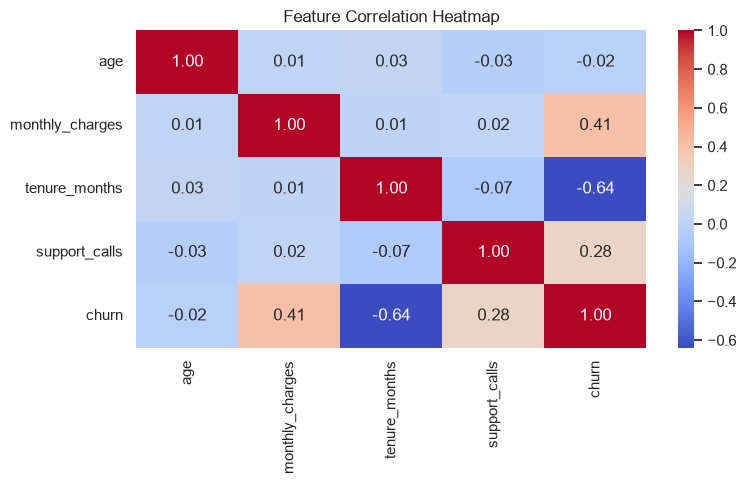

C:\Users\user\AppData\Local\Temp\ipykernel_22744\519079516.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='support_calls', y='churn', palette='viridis')


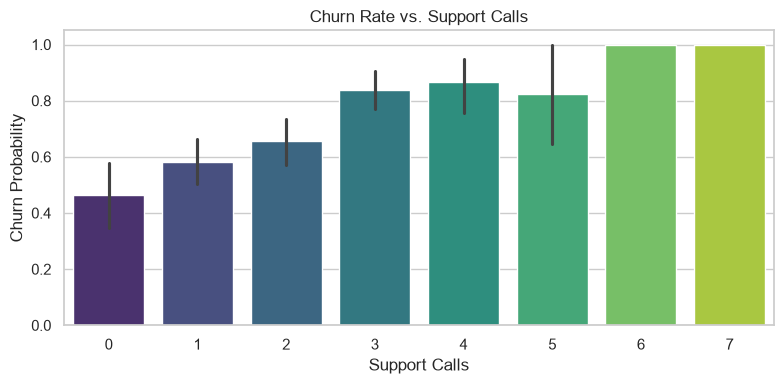

In [4]:
# 1. Plot feature correlations
plt.figure(figsize=(8, 5))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# 2. Visualize churn rate by support calls
plt.figure(figsize=(8, 4))
sns.barplot(data=data, x='support_calls', y='churn', palette='viridis')
plt.title("Churn Rate vs. Support Calls")
plt.xlabel("Support Calls")
plt.ylabel("Churn Probability")
plt.tight_layout()
plt.show()

In [5]:
# Define features (X) and target (y)
X = data[['age', 'monthly_charges', 'tenure_months', 'support_calls']]
y = data['churn']

# Split: 80% training set, 20% test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size:  {X_test.shape[0]} samples")

Training set size: 400 samples
Testing set size:  100 samples


In [6]:
# Initialize and fit model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


Accuracy: 95.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92        33
           1       0.96      0.97      0.96        67

    accuracy                           0.95       100
   macro avg       0.95      0.94      0.94       100
weighted avg       0.95      0.95      0.95       100



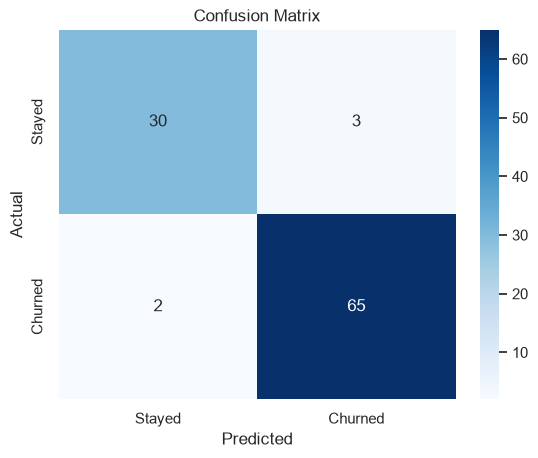

In [7]:
# Generate predictions
y_pred = model.predict(X_test)

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%\n")

# Detailed Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_22744\3958048629.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance, y=feature_importance.index, palette='mako')


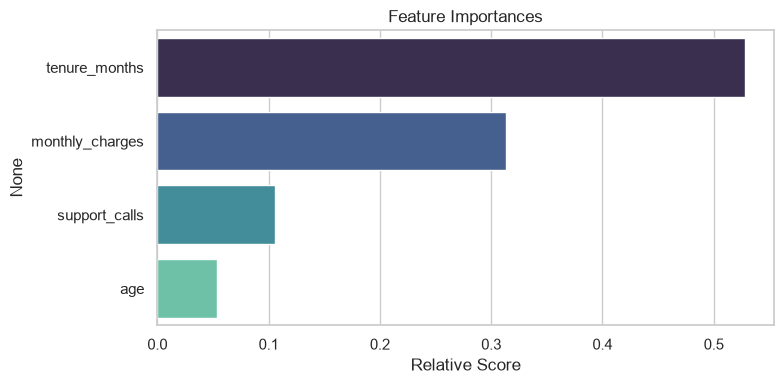

In [8]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=feature_importance, y=feature_importance.index, palette='mako')
plt.title("Feature Importances")
plt.xlabel("Relative Score")
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import os

# Check CSV files inside your Downloads folder
downloads_path = r'C:\Users\user\Downloads'
csv_files = [f for f in os.listdir(downloads_path) if f.endswith('.csv')]

print("CSV files found in Downloads:")
print(csv_files)

# If a CSV file exists, load the first one automatically
if csv_files:
    file_path = os.path.join(downloads_path, csv_files[0])
    data = pd.read_csv(file_path)
    print(f"\nSuccessfully loaded: {csv_files[0]}")
    print(data.head())
else:
    print("\nNo CSV file found in Downloads. Check the exact filename.")

CSV files found in Downloads:
['student_performance.csv']

Successfully loaded: student_performance.csv
   Student_ID  Gender  Study_Hours  Attendance  Previous_Score  Final_Score
0           1    Male          2.5        65.0            58.0           61
1           2  Female          4.0        82.0            72.0           78
2           3    Male          3.0        75.0            65.0           68
3           4  Female          5.5        90.0            81.0           88
4           5    Male          1.5        55.0            48.0           50


In [ ]:
import pandas as pd
import os

# Select your specific file name from the list
file_name = 'student_performance.csv'  # <--- Change this to your file name
file_path = os.path.join(r'C:\Users\user\Downloads', student_performance.csv)

# Load the dataset
data = pd.read_csv(file_path)

# Display columns, data types, and first few rows
print("Dataset loaded successfully!\n")
print("Column Names:")
print(list(data.columns))

print("\nFirst 5 Rows:")
data.head()

In [5]:
import pandas as pd

# 1. Drop unnecessary columns
data_clean = data.drop(columns=['Student_ID'])

# 2. Convert text column 'Gender' into numeric format (One-Hot Encoding)
data_clean = pd.get_dummies(data_clean, columns=['Gender'], drop_first=True)

# View processed columns
print("Cleaned Dataset Head:")
print(data_clean.head())

Cleaned Dataset Head:
   Study_Hours  Attendance  Previous_Score  Final_Score  Gender_Male
0          2.5        65.0            58.0           61         True
1          4.0        82.0            72.0           78        False
2          3.0        75.0            65.0           68         True
3          5.5        90.0            81.0           88        False
4          1.5        55.0            48.0           50         True


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define Features (X) and Target (y)
X = data_clean.drop(columns=['Final_Score'])
y = data_clean['Final_Score']

# Split into 80% Training set and 20% Testing set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize and train the regression model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


Mean Absolute Error (MAE): 1.22
Root Mean Squared Error (RMSE): 1.44
R-squared Score (Accuracy Fit): 99.19%



C:\Users\user\AppData\Local\Temp\ipykernel_20044\1707178642.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance, y=feature_importance.index, palette='mako')


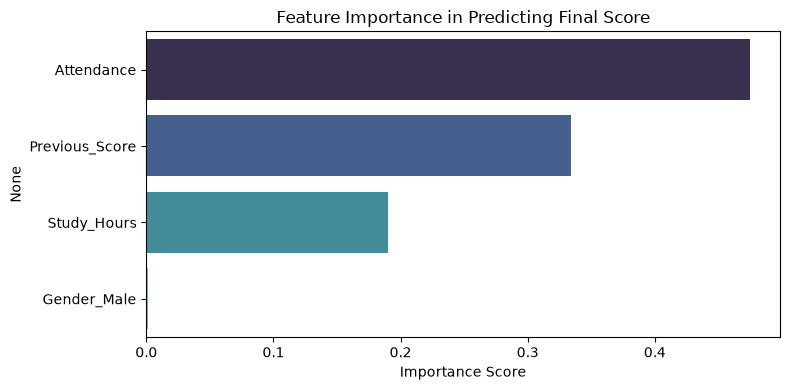

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score (Accuracy Fit): {r2 * 100:.2f}%\n")

# Plot Feature Importances
feature_importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=feature_importance, y=feature_importance.index, palette='mako')
plt.title("Feature Importance in Predicting Final Score")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [8]:
print("Expected features:", list(X.columns))

Expected features: ['Study_Hours', 'Attendance', 'Previous_Score', 'Gender_Male']


In [9]:
import pandas as pd

# Define details for a new student
# Note: For 'Gender_Male', use 1 for Male, 0 for Female
new_student_data = pd.DataFrame([{
    'Study_Hours': 4.5,
    'Attendance': 88.0,
    'Previous_Score': 75.0,
    'Gender_Male': 1  # 1 = Male, 0 = Female
}])

# Make prediction using the trained model
predicted_score = model.predict(new_student_data)

print(f"Predicted Final Score: {predicted_score[0]:.2f}")

Predicted Final Score: 81.31


In [10]:
# Multiple students
new_students = pd.DataFrame([
    {'Study_Hours': 1.0, 'Attendance': 50.0, 'Previous_Score': 45.0, 'Gender_Male': 1},
    {'Study_Hours': 6.0, 'Attendance': 95.0, 'Previous_Score': 88.0, 'Gender_Male': 0}
])

predictions = model.predict(new_students)

for i, score in enumerate(predictions, start=1):
    print(f"Student {i} Predicted Score: {score:.2f}")

Student 1 Predicted Score: 49.00
Student 2 Predicted Score: 92.73


In [11]:
import joblib

# Save the trained model to a file named 'student_model.joblib'
joblib.dump(model, 'student_model.joblib')

print("Model saved successfully as 'student_model.joblib'!")

Model saved successfully as 'student_model.joblib'!


In [12]:
import joblib
import pandas as pd

# Load the model back into memory
loaded_model = joblib.load('student_model.joblib')

print("Model loaded successfully!")

# Test a prediction with the reloaded model
sample_student = pd.DataFrame([{
    'Study_Hours': 5.0,
    'Attendance': 90.0,
    'Previous_Score': 80.0,
    'Gender_Male': 0  # Female
}])

predicted_score = loaded_model.predict(sample_student)
print(f"Predicted Final Score: {predicted_score[0]:.2f}")

Model loaded successfully!
Predicted Final Score: 85.54


In [13]:
# Check dataset structure and summary statistics
print("--- Missing Values Check ---")
print(data.isnull().sum())

print("\n--- Summary Statistics ---")
print(data.describe())

# Clean data: drop ID and encode categorical variables
data_clean = data.drop(columns=['Student_ID'])
data_clean = pd.get_dummies(data_clean, columns=['Gender'], drop_first=True)

# Fill any missing values if present
data_clean = data_clean.fillna(data_clean.mean())

--- Missing Values Check ---
Student_ID        0
Gender            1
Study_Hours       1
Attendance        1
Previous_Score    1
Final_Score       0
dtype: int64

--- Summary Statistics ---
       Student_ID  Study_Hours  Attendance  Previous_Score  Final_Score
count   41.000000    40.000000   40.000000       40.000000    41.000000
mean    20.292683     4.050000   78.650000       70.950000    75.512195
std     11.619475     1.651728   12.737085       12.804146    13.366230
min      1.000000     1.000000   50.000000       45.000000    47.000000
25%     11.000000     2.875000   69.750000       61.750000    66.000000
50%     20.000000     4.000000   79.500000       70.500000    76.000000
75%     30.000000     5.125000   89.250000       80.250000    87.000000
max     40.000000     7.500000   99.000000       94.000000    98.000000


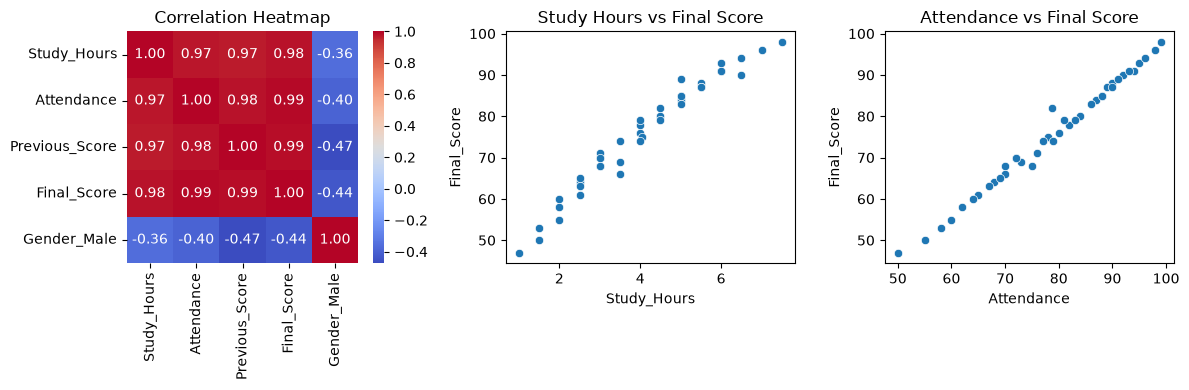

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 4))

# Chart 1: Feature Correlation Heatmap
plt.subplot(1, 3, 1)
sns.heatmap(data_clean.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")

# Chart 2: Study Hours vs Final Score
plt.subplot(1, 3, 2)
sns.scatterplot(data=data_clean, x='Study_Hours', y='Final_Score')
plt.title("Study Hours vs Final Score")

# Chart 3: Attendance vs Final Score
plt.subplot(1, 3, 3)
sns.scatterplot(data=data_clean, x='Attendance', y='Final_Score')
plt.title("Attendance vs Final Score")

plt.tight_layout()
plt.show()

Linear Regression Intercept: 43.40
Linear Regression Slope (Coefficient): 7.95
R-squared Score: 94.88%


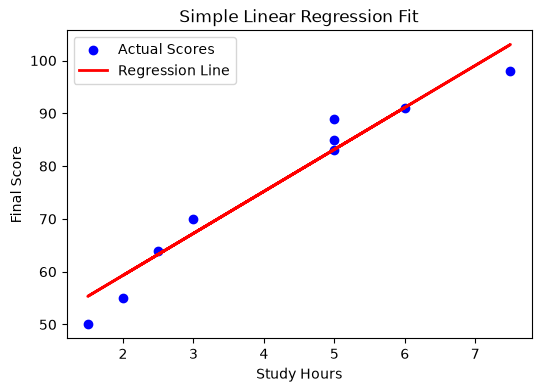

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Simple Linear Regression uses ONE feature (e.g., Study_Hours) to predict Final_Score
X_simple = data_clean[['Study_Hours']]
y = data_clean['Final_Score']

# Split data
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train_s, y_train_s)

# Predict & Evaluate
y_pred_s = lr_model.predict(X_test_s)

print(f"Linear Regression Intercept: {lr_model.intercept_:.2f}")
print(f"Linear Regression Slope (Coefficient): {lr_model.coef_[0]:.2f}")
print(f"R-squared Score: {r2_score(y_test_s, y_pred_s) * 100:.2f}%")

# Plot Regression Line
plt.figure(figsize=(6, 4))
plt.scatter(X_test_s, y_test_s, color='blue', label='Actual Scores')
plt.plot(X_test_s, y_pred_s, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Study Hours')
plt.ylabel('Final Score')
plt.title('Simple Linear Regression Fit')
plt.legend()
plt.show()

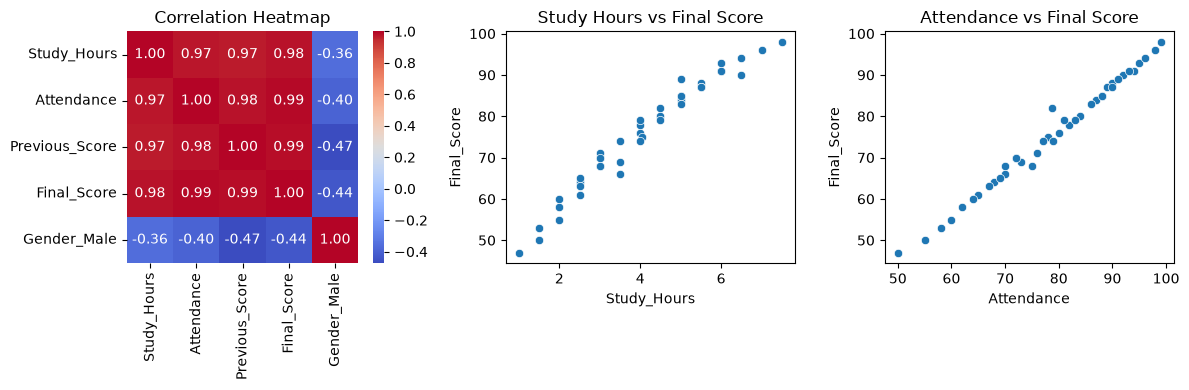

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 4))

# Correlation Heatmap
plt.subplot(1, 3, 1)
sns.heatmap(data_clean.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")

# Study Hours vs Final Score
plt.subplot(1, 3, 2)
sns.scatterplot(data=data_clean, x='Study_Hours', y='Final_Score')
plt.title("Study Hours vs Final Score")

# Attendance vs Final Score
plt.subplot(1, 3, 3)
sns.scatterplot(data=data_clean, x='Attendance', y='Final_Score')
plt.title("Attendance vs Final Score")

plt.tight_layout()
plt.show()

Intercept: 43.40
Slope (Coefficient): 7.95
R-squared Score: 94.88%


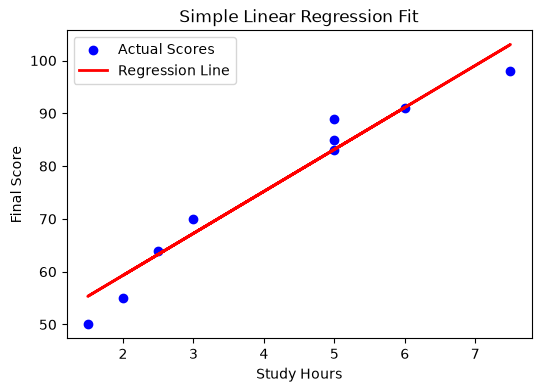

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Prepare single feature (Study_Hours) and target (Final_Score)
X_simple = data_clean[['Study_Hours']]
y = data_clean['Final_Score']

# Split data
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Train Simple Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train_s, y_train_s)

# Predict & Evaluate
y_pred_s = lr_model.predict(X_test_s)

print(f"Intercept: {lr_model.intercept_:.2f}")
print(f"Slope (Coefficient): {lr_model.coef_[0]:.2f}")
print(f"R-squared Score: {r2_score(y_test_s, y_pred_s) * 100:.2f}%")

# Plot regression line
plt.figure(figsize=(6, 4))
plt.scatter(X_test_s, y_test_s, color='blue', label='Actual Scores')
plt.plot(X_test_s, y_pred_s, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Study Hours')
plt.ylabel('Final Score')
plt.title('Simple Linear Regression Fit')
plt.legend()
plt.show()